In [99]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [100]:
df = pd.read_csv('hr.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0


## **Age**: Edad del empleado.
- **Attrition**: Indica si el empleado dejó la empresa (Yes/No).
- **BusinessTravel**: Frecuencia de viajes laborales (e.g., travel_rarely).
- **DailyRate**: Tarifa diaria estimada para clientes, calculada en base al salario.
- **Department**: Departamento en el que trabaja el empleado.
- **DistanceFromHome**: Distancia en millas o kilómetros desde el hogar al trabajo.
- **Education**: Nivel educativo del empleado en escala numérica.
- **EducationField**: Campo de estudio académico del empleado.
- **employeecount**: Valor constante de "1", indicando un solo empleado por registro.
- **employeenumber**: Número de identificación del empleado.
- **EnvironmentSatisfaction**: Nivel de satisfacción con el ambiente laboral.
- **Gender**: Género del empleado.
- **HourlyRate**: Tarifa por hora calculada.
- **JobInvolvement**: Nivel de compromiso del empleado en el trabajo.
- **JobLevel**: Nivel jerárquico del puesto del empleado.
- **JobRole**: Función o rol específico del empleado.
- **JobSatisfaction**: Satisfacción general en el puesto.
- **MaritalStatus**: Estado civil (e.g., Single, Married).
- **MonthlyIncome**: Ingreso mensual estimado en base al salario anual.
- **MonthlyRate**: Tarifa mensual estimada en función de la tarifa diaria.
- **NUMCOMPANIESWORKED**: Número de empresas previas en las que ha trabajado.
- **OverTime**: Indica si el empleado trabaja horas extras (Yes/No).
- **PercentSalaryHike**: Incremento porcentual en el salario.
- **PerformanceRating**: Evaluación de desempeño en una escala numérica.
- **RelationshipSatisfaction**: Satisfacción con relaciones interpersonales en el trabajo.
- **StandardHours**: Clasificación de jornada (Full Time/Part Time).
- **StockOptionLevel**: Nivel de opciones sobre acciones asignadas.
- **TOTALWORKINGYEARS**: Años totales de experiencia laboral.
- **TrainingTimesLastYear**: Número de sesiones de entrenamiento en el último año.
- **WORKLIFEBALANCE**: Nivel de balance entre vida personal y laboral.
- **YearsAtCompany**: Años en la empresa actual.
- **YearsInCurrentRole**: Años en el rol actual.
- **YearsSinceLastPromotion**: Años desde la última prom
oción recibida.
- **YEARSWITHCURRMANAGER**: Años trabajando con el mismo gerente.

In [101]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   str    
 2   BusinessTravel            1357 non-null   str    
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   str    
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   str    
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   str    
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non-null   int64  
 14  JobLevel           

In [102]:
df.isnull().sum()

Age                          73
Attrition                     0
BusinessTravel              117
DailyRate                     0
Department                   29
DistanceFromHome              0
Education                     0
EducationField               58
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction              29
MaritalStatus               132
MonthlyIncome                14
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                     44
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours               164
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear        88
WorkLifeBalance               0
YearsAtC

In [103]:
df.duplicated().sum()

np.int64(4)

In [104]:
df[df["EmployeeNumber"].duplicated(keep=False)].sort_values("EmployeeNumber").head(20)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
67,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
184,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1041,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1222,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0


In [105]:
df.drop_duplicates(keep='first', inplace=True)

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1397 non-null   float64
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1353 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1441 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1412 non-null   str    
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
(df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)

StandardHours               10.952381
YearsWithCurrManager        10.000000
MaritalStatus                8.979592
BusinessTravel               7.959184
TrainingTimesLastYear        5.986395
Age                          4.965986
EducationField               3.945578
OverTime                     2.993197
JobSatisfaction              1.972789
Department                   1.972789
MonthlyIncome                0.952381
Attrition                    0.000000
EmployeeNumber               0.000000
EmployeeCount                0.000000
Gender                       0.000000
EnvironmentSatisfaction      0.000000
Education                    0.000000
DistanceFromHome             0.000000
DailyRate                    0.000000
JobRole                      0.000000
HourlyRate                   0.000000
JobInvolvement               0.000000
JobLevel                     0.000000
Over18                       0.000000
PercentSalaryHike            0.000000
NumCompaniesWorked           0.000000
MonthlyRate 

In [109]:
df['YearsWithCurrManager'].unique()

array([ 5.,  7.,  0.,  2.,  6., nan,  8.,  3., 11., 17.,  4.,  1., 12.,
        9., 10., 15., 13., 16., 14.])

In [110]:
df['MaritalStatus'].unique()

<ArrowStringArray>
['Single', 'Married', 'Divorced', nan, 'Marreid']
Length: 5, dtype: str

In [111]:
df['BusinessTravel'].unique()

<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel', nan]
Length: 4, dtype: str

In [112]:
df['TrainingTimesLastYear'].unique()

array([ 0.,  3.,  2.,  5.,  1.,  4., nan,  6.])

In [113]:
df['Age'].unique()

array([41., 49., 37., 33., 27., 32., 59., 30., 38., 36., 35., 29., 31.,
       34., 28., 22., 53., 24., 21., 42., 44., 46., 39., 43., 50., 26.,
       48., nan, 55., 45., 56., 23., 51., 40., 54., 58., 20., 25., 19.,
       57., 52., 47., 18., 60.])

In [114]:
df['EducationField'].unique()

<ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
                nan,        'Marketing', 'Technical Degree',
  'Human Resources']
Length: 7, dtype: str

In [115]:
df['OverTime'].unique()

<ArrowStringArray>
['Yes', 'No', nan]
Length: 3, dtype: str

In [116]:
df['JobSatisfaction'].unique()

array([ 4.,  2.,  3.,  1., nan])

In [117]:
df['Department'].unique()

<ArrowStringArray>
['Sales', 'Research & Development', nan, 'Human Resources']
Length: 4, dtype: str

In [118]:
df['MonthlyIncome'].max()

np.float64(19999.0)

In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1397 non-null   float64
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1353 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1441 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1412 non-null   str    
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [120]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0
2,37.0,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3.0,Single,2090.0,2396,6,Y,Yes,15,3,2,NaN,0,7,3.0,3,0,0,0,0.0
3,33.0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,rESEARCH sCIENTIST,3.0,Married,2909.0,23159,1,Y,Yes,11,3,3,80.0,0,8,3.0,3,8,7,3,0.0
4,27.0,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2.0,Married,3468.0,16632,9,Y,No,12,3,4,80.0,1,6,3.0,3,2,2,2,2.0


In [121]:
df['StockOptionLevel'].unique()

array([0, 1, 3, 2])

In [122]:
df['PercentSalaryHike'].unique()

array([11, 23, 15, 12, 13, 20, 22, 21, 17, 14, 16, 18, 19, 24, 25])

In [123]:
df['Over18'].unique()

<ArrowStringArray>
['Y']
Length: 1, dtype: str

In [124]:
df['EmployeeCount'].unique()

array([1])

In [125]:
columnas = ['DailyRate', 'MonthlyRate'] 
for col in columnas:
    df[col]= df[col].astype(float)

In [126]:
columnas = ['Age', 'YearsWithCurrManager', 'TrainingTimesLastYear', 'JobSatisfaction']
for col in columnas:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1397 non-null   Int64  
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1353 non-null   str    
 3   DailyRate                 1470 non-null   float64
 4   Department                1441 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1412 non-null   str    
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   str    
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel           

In [128]:
df['Age'].unique()

<IntegerArray>
[  41,   49,   37,   33,   27,   32,   59,   30,   38,   36,   35,   29,   31,
   34,   28,   22,   53,   24,   21,   42,   44,   46,   39,   43,   50,   26,
   48, <NA>,   55,   45,   56,   23,   51,   40,   54,   58,   20,   25,   19,
   57,   52,   47,   18,   60]
Length: 44, dtype: Int64

In [129]:
cols_drop = ['StandardHours', 'EmployeeCount', 'Over18']
df.drop(columns=cols_drop, inplace=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,2,Female,94,3,2,sALES eXECUTIVE,4,Single,5993.0,19479.0,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,rESEARCH sCIENTIST,2,Married,5130.0,24907.0,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2,2,Other,4,4,Male,92,2,1,lABORATORY tECHNICIAN,3,Single,2090.0,2396.0,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,rESEARCH sCIENTIST,3,Married,2909.0,23159.0,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591.0,Research & Development,2,1,Medical,7,1,Male,40,3,1,lABORATORY tECHNICIAN,2,Married,3468.0,16632.0,9,No,12,3,4,1,6,3,3,2,2,2,2


In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1397 non-null   Int64  
 1   Attrition                 1470 non-null   str    
 2   BusinessTravel            1353 non-null   str    
 3   DailyRate                 1470 non-null   float64
 4   Department                1441 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1412 non-null   str    
 8   EmployeeNumber            1470 non-null   int64  
 9   EnvironmentSatisfaction   1470 non-null   int64  
 10  Gender                    1470 non-null   str    
 11  HourlyRate                1470 non-null   int64  
 12  JobInvolvement            1470 non-null   int64  
 13  JobLevel                  1470 non-null   int64  
 14  JobRole            

In [131]:
df['MaritalStatus'].unique()

<ArrowStringArray>
['Single', 'Married', 'Divorced', nan, 'Marreid']
Length: 5, dtype: str

In [132]:
df['MaritalStatus'] = df['MaritalStatus'].replace({'Marreid': 'Married'})

In [133]:
df['JobRole'] = df['JobRole'].astype(str).str.strip().str.capitalize()


In [134]:
df['JobRole'].unique()

<ArrowStringArray>
[          'Sales executive',        'Research scientist',
     'Laboratory technician',    'Manufacturing director',
 'Healthcare representative',                   'Manager',
      'Sales representative',         'Research director',
           'Human resources']
Length: 9, dtype: str

In [197]:
mapa = {
    'Laboratory technician': 'Research & Development',
    'Sales executive': 'Sales',
    'Research scientist': 'Research & Development',
    'Research director': 'Research & Development',
    'Healthcare representative': 'Research & Development',
    'Manufacturing director': 'Research & Development',
    'Manager': 'Unknown',
}

mask = df['Department'] == 'Unknown'
df.loc[mask, 'Department'] = df.loc[mask, 'JobRole'].map(mapa)

In [199]:
df['Department'].value_counts()

Department
Research & Development    959
Sales                     446
Human Resources            63
Unknown                     2
Name: count, dtype: int64

In [136]:
# añadir al nombre de la columna PercentSalaryHike el (%)
df.rename(columns={'PercentSalaryHike': 'PercentSalaryHike (%)'}, inplace=True)

In [137]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike (%),PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales executive,4,Single,5993.0,19479.0,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research scientist,2,Married,5130.0,24907.0,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory technician,3,Single,2090.0,2396.0,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research scientist,3,Married,2909.0,23159.0,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591.0,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory technician,2,Married,3468.0,16632.0,9,No,12,3,4,1,6,3,3,2,2,2,2


In [138]:
df.isnull().sum()

Age                          73
Attrition                     0
BusinessTravel              117
DailyRate                     0
Department                   29
DistanceFromHome              0
Education                     0
EducationField               58
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction              29
MaritalStatus               132
MonthlyIncome                14
MonthlyRate                   0
NumCompaniesWorked            0
OverTime                     44
PercentSalaryHike (%)         0
PerformanceRating             0
RelationshipSatisfaction      0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear        88
WorkLifeBalance               0
YearsAtCompany                0
YearsInCurrentRole            0
YearsSinceLastPromotion       0
YearsWit

In [139]:
df['YearsWithCurrManager'].unique()

<IntegerArray>
[5, 7, 0, 2, 6, <NA>, 8, 3, 11, 17, 4, 1, 12, 9, 10, 15, 13, 16, 14]
Length: 19, dtype: Int64

In [140]:
cols_fill = ['OverTime', 'BusinessTravel', 'MaritalStatus', 'Department', 'EducationField']
for col in cols_fill:
    df[col] = df[col].fillna('Unknown')

In [141]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike (%),PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102.0,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales executive,4,Single,5993.0,19479.0,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279.0,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research scientist,2,Married,5130.0,24907.0,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373.0,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory technician,3,Single,2090.0,2396.0,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392.0,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research scientist,3,Married,2909.0,23159.0,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591.0,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory technician,2,Married,3468.0,16632.0,9,No,12,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005.0,Research & Development,2,2,Life Sciences,8,4,Male,79,3,1,Laboratory technician,4,Single,3068.0,11864.0,0,No,13,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324.0,Research & Development,3,3,Medical,10,3,Female,81,4,1,Laboratory technician,1,Married,2670.0,9964.0,4,Unknown,20,4,1,3,12,3,2,1,0,0,<NA>
7,30,No,Travel_Rarely,1358.0,Unknown,24,1,Life Sciences,11,4,Male,67,3,1,Laboratory technician,3,Divorced,2693.0,13335.0,1,No,22,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216.0,Research & Development,23,3,Life Sciences,12,4,Male,44,2,3,Manufacturing director,3,Single,9526.0,8787.0,0,No,21,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299.0,Research & Development,27,3,Unknown,13,3,Male,94,3,2,Healthcare representative,3,Married,5237.0,16577.0,6,No,13,3,2,2,17,3,2,7,7,7,<NA>


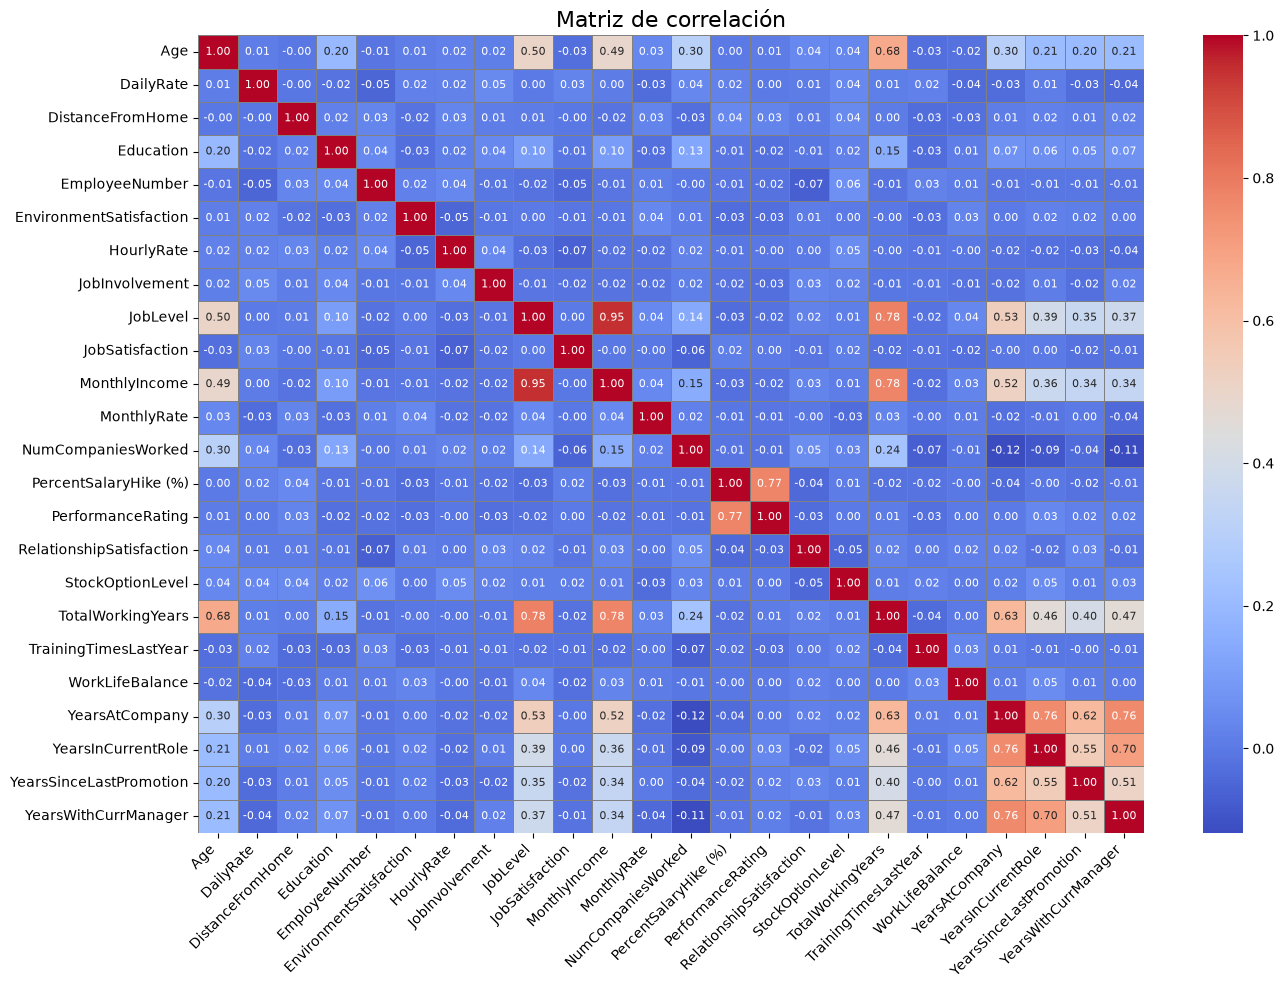

In [142]:
num = df.select_dtypes(include=np.number).columns
matriz= df[num].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 8}
)
plt.title('Matriz de correlación', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [143]:
df_attrition_yes = df[df['Attrition'] == 'Yes']
df_attrition_no = df[df['Attrition'] == 'No']

In [144]:
len(df_attrition_yes)

237

In [145]:
len(df_attrition_no)

1233

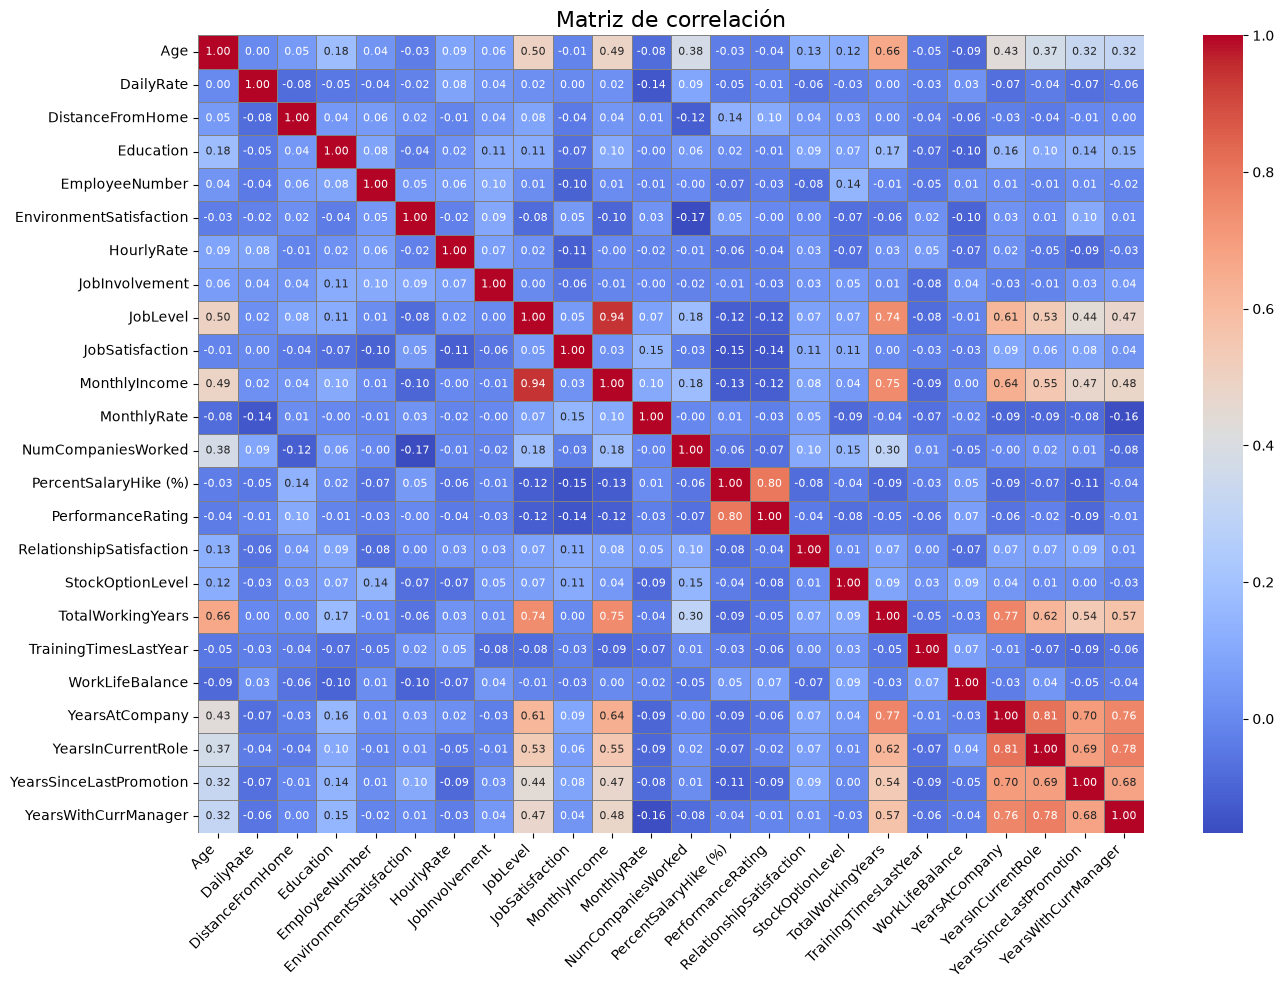

In [146]:
num = df_attrition_yes.select_dtypes(include=np.number).columns
matriz= df_attrition_yes[num].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 8}
)
plt.title('Matriz de correlación', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

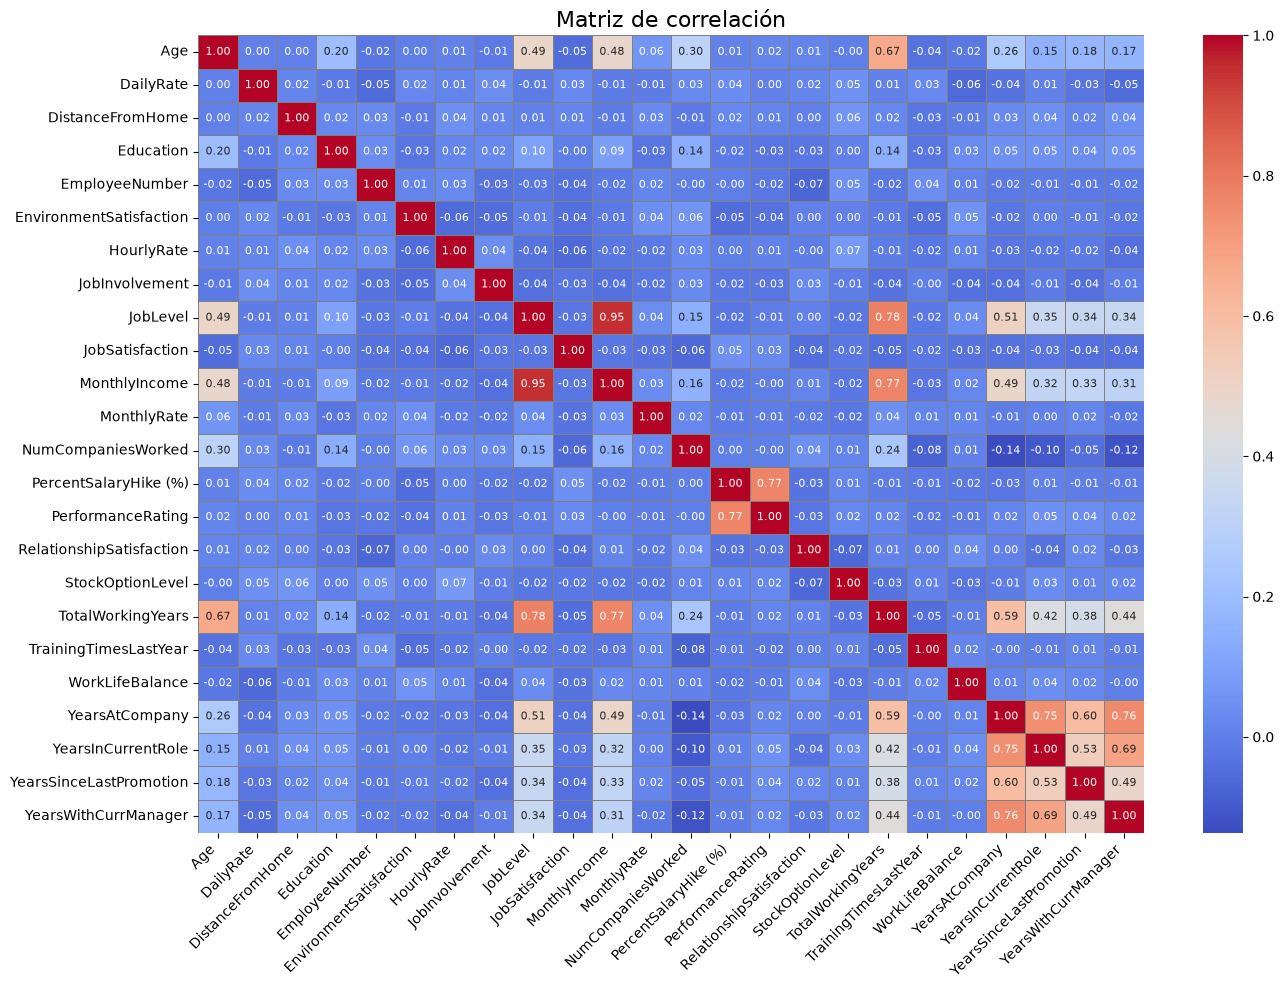

In [147]:
num = df_attrition_no.select_dtypes(include=np.number).columns
matriz= df_attrition_no[num].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={'size': 8}
)
plt.title('Matriz de correlación', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [227]:
df['Department'].value_counts()

Department
Research & Development    959
Sales                     446
Human Resources            63
Unknown                     2
Name: count, dtype: int64

In [228]:
df.to_excel('hr_cleaned.xlsx', index=False)
print("Archivo guardado: hr_cleaned.xlsx")

Archivo guardado: hr_cleaned.xlsx


## ANALISIS

- ¿Quien se va?

In [148]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [149]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

- El porcentaje de empleados abandona la empresa: 16%

# ¿Los empleados jóvenes abandonan más?

In [150]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1177.0,37.553101,8.847582,18.0,31.0,36.0,43.0,60.0
Yes,220.0,33.677273,9.710439,18.0,28.0,32.0,39.0,58.0


<Axes: xlabel='Age', ylabel='Attrition'>

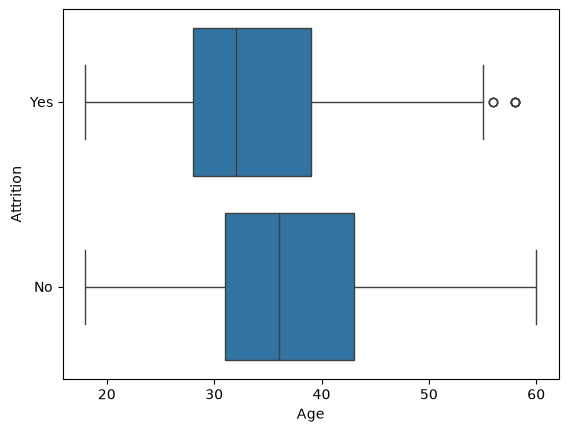

In [151]:
sns.boxplot(data=df,
            y="Attrition",
            x="Age")

In [152]:
df.groupby("Attrition")["Age"].mean()

Attrition
No     37.553101
Yes    33.677273
Name: Age, dtype: Float64

-La media de edad de los empleados que se van es de  33 años 

# ¿Cobrar poco influye? *

<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

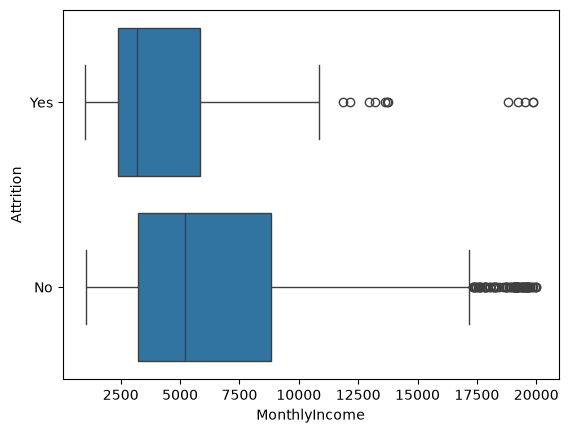

In [153]:
sns.boxplot(
    data=df,
    y="Attrition",
    x="MonthlyIncome"
)

In [154]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1223.0,6830.937040,4818.188433,1051.0,3210.5,5204.0,8835.5,19999.0
Yes,233.0,4754.708155,3630.120692,1009.0,2367.0,3202.0,5828.0,19859.0


In [155]:
df.groupby("Attrition")["MonthlyIncome"].median()

Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64

In [156]:
df.groupby("Attrition")["MonthlyIncome"].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None)

Attrition
No     2342.0
Yes    2293.0
Name: MonthlyIncome, dtype: float64

- Los empleados que abandonan la empresa perciben un salario inferior al del resto de empleados

# Horas extra

<Axes: xlabel='OverTime', ylabel='count'>

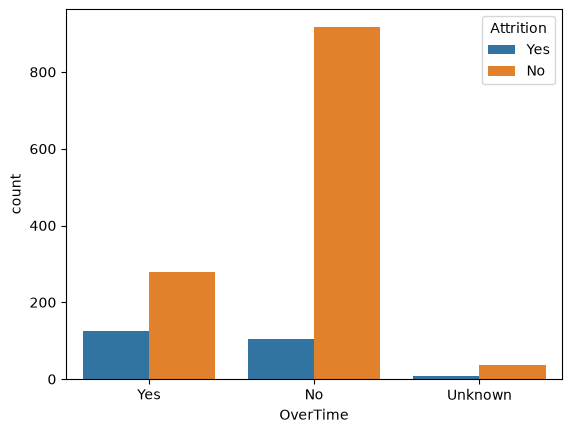

In [157]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

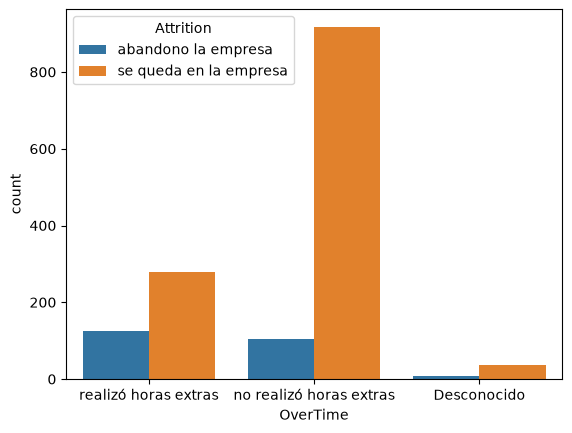

In [158]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)
ax = plt.gca()
# renombrar etiquetas del eje x
xticks = [t.get_text() for t in ax.get_xticklabels()]
xt_map = {'Yes': 'realizó horas extras', 'No': 'no realizó horas extras', 'Unknown': 'Desconocido'}
ax.set_xticklabels([xt_map.get(t, t) for t in xticks])

# renombrar etiquetas de la leyenda (hue)
handles, labels = ax.get_legend_handles_labels()
legend_map = {'Yes': 'abandono la empresa', 'No': 'se queda en la empresa'}
ax.legend(handles=handles, labels=[legend_map.get(l, l) for l in labels], title='Attrition')

In [159]:
pd.crosstab(df["OverTime"],
            df["Attrition"],
            normalize="index")*100

Attrition,No,Yes
OverTime,,
No,89.813908,10.186092
Unknown,81.818182,18.181818
Yes,69.135802,30.864198


- Entre los empleados que no realizan horas extra, únicamente el 10 % abandona la empresa. En cambio, entre quienes sí realizan horas extra, el abandono asciende al 30 %

# Satisfacción laboral *

In [160]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobSatisfaction,,
1,77.385159,22.614841
2,83.272727,16.727273
3,83.644860,16.355140
4,88.791209,11.208791


In [161]:
df_attrition_yes = df[df['Attrition'] == 'Yes']
df_attrition_no = df[df['Attrition'] == 'No']

<Axes: xlabel='JobSatisfaction', ylabel='count'>

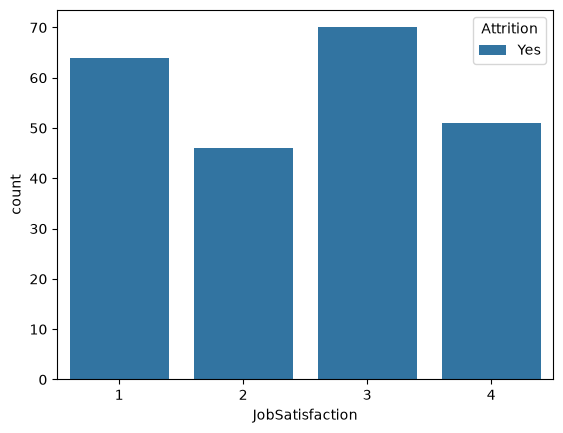

In [162]:
sns.countplot(
    data=df_attrition_yes,
    x="JobSatisfaction",
    hue="Attrition"
)

In [163]:
(df_attrition_yes['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)


JobSatisfaction
1    27.71
2    19.91
3     30.3
4    22.08
Name: proportion, dtype: Float64

In [164]:
(df_attrition_no['JobSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

JobSatisfaction
1     18.1
2    18.93
3    29.59
4    33.39
Name: proportion, dtype: Float64

 ¿La gente menos satisfecha se marcha más? SI . El 27,71 % de los empleados con satisfacción 1 abandonan la empresa, mientras que el 22,08 % de los empleados con satisfacción 4 lo hacen.

In [165]:
# El análisis de la satisfacción laboral muestra que los empleados que abandonan la empresa tienen una mayor proporción de insatisfacción laboral en comparación con aquellos que permanecen en la empresa. 
# Esto sugiere que la satisfacción laboral podría ser un factor importante en la retención de empleados.

In [166]:
# El 48% de los empleados que abandonan la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Mientras que el 36% de los empleados que permanecen en la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Esto indica que la insatisfacción laboral es más prevalente entre los empleados que abandonan la empresa, lo que podría ser un indicador clave para la gestión de recursos humanos y la implementación de estrategias de retención.

# Work Life Balance

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

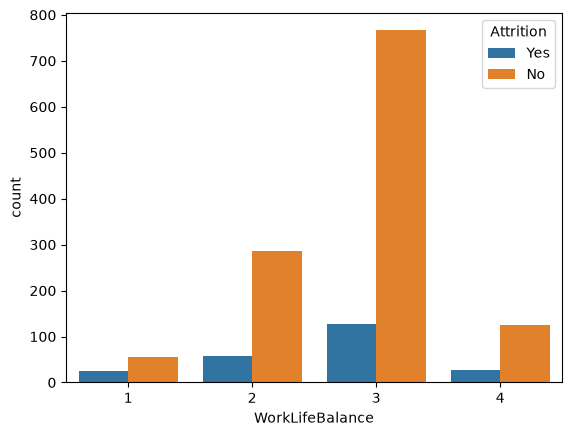

In [167]:
sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

- 

# Environment Satisfaction *

In [168]:
pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


<Axes: xlabel='EnvironmentSatisfaction', ylabel='count'>

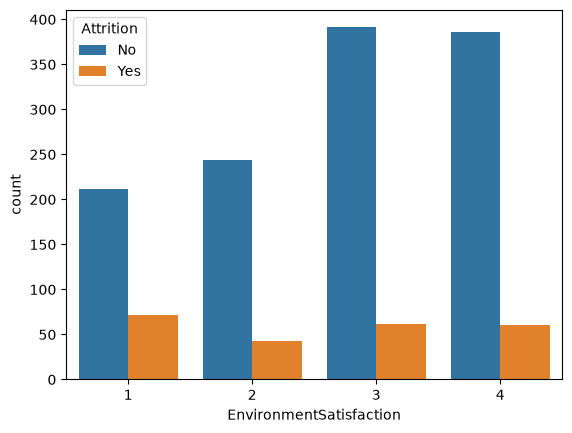

In [169]:
sns.countplot(
    data=df,
    x="EnvironmentSatisfaction",
    hue="Attrition"
)

- 

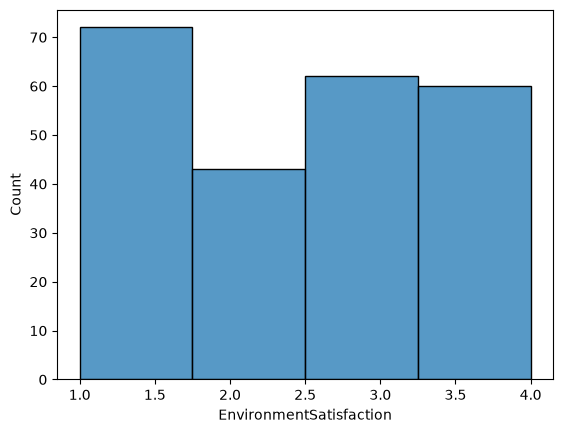

In [170]:
sns.histplot(data=df_attrition_yes, x='EnvironmentSatisfaction', bins=4)
plt.show()

In [171]:
(df_attrition_yes['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

EnvironmentSatisfaction
1    30.38
2    18.14
3    26.16
4    25.32
Name: proportion, dtype: float64

In [172]:
(df_attrition_no['EnvironmentSatisfaction'].value_counts(normalize=True).sort_index() * 100).round(2)

EnvironmentSatisfaction
1    17.19
2    19.79
3    31.71
4    31.31
Name: proportion, dtype: float64

In [173]:
# El 48% de los empleados que abandonan la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Mientras que el 37% de los empleados que permanecen en la empresa tienen un nivel de satisfaccion laboral de 1 y 2. Esto indica que la insatisfacción laboral es más prevalente entre los empleados que abandonan la empresa, lo que podría ser un indicador clave para la gestión de recursos humanos y la implementación de estrategias de retención.

# Job Involvement

In [174]:
pd.crosstab(
    df["JobInvolvement"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


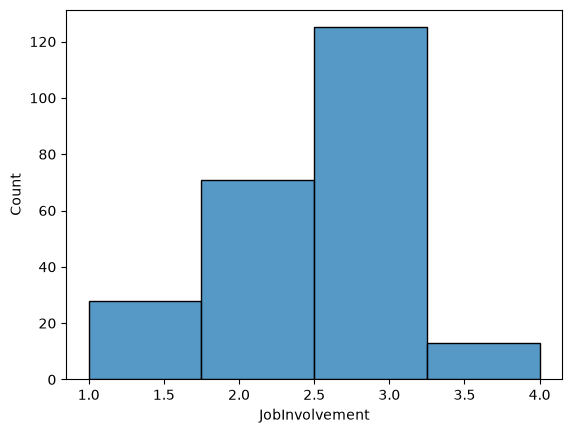

In [175]:
sns.histplot(data=df_attrition_yes, x='JobInvolvement', bins=4)
plt.show()

In [176]:
(df_attrition_yes['JobInvolvement'].value_counts(normalize=True).sort_index() * 100).round(2)

JobInvolvement
1    11.81
2    29.96
3    52.74
4     5.49
Name: proportion, dtype: float64

In [177]:
(df_attrition_no['JobInvolvement'].value_counts(normalize=True).sort_index() * 100).round(2)

JobInvolvement
1     4.46
2    24.66
3    60.26
4    10.62
Name: proportion, dtype: float64

# Departamento que pierde mas empleados *

In [214]:
mapa = {
    'Laboratory technician': 'Research & Development',
    'Sales executive': 'Sales',
    'Research scientist': 'Research & Development',
    'Research director': 'Research & Development',
    'Healthcare representative': 'Research & Development',
    'Manufacturing director': 'Research & Development',
    'Manager': 'Unknown',
}

mask = df['Department'] == 'Unknown'
df.loc[mask, 'Department'] = df.loc[mask, 'JobRole'].map(mapa)

In [216]:
pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.131387,13.868613
Sales,79.372197,20.627803
Unknown,100.000000,0.000000


In [219]:
df['Department'].value_counts()

Department
Research & Development    959
Sales                     446
Human Resources            63
Unknown                     2
Name: count, dtype: int64

<Axes: xlabel='Department', ylabel='count'>

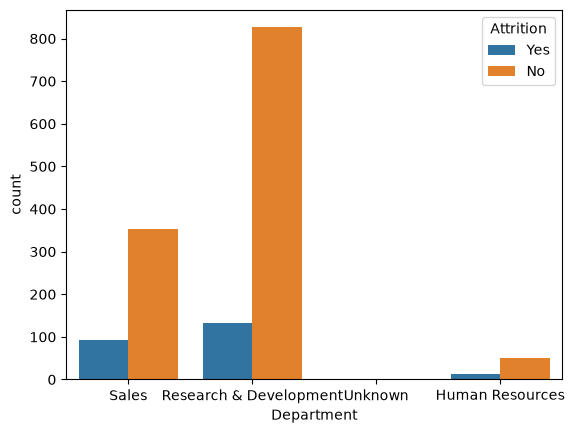

In [220]:
sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

- se aprecia clarmente que el departamento de Research & Development es el pierde mayor cantidad de empleados

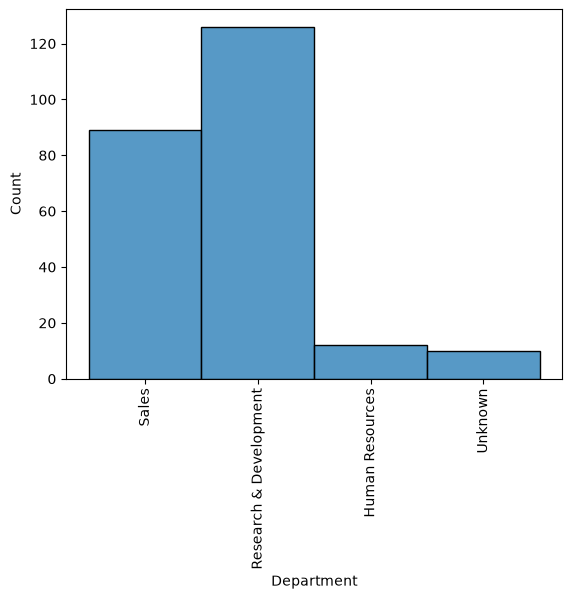

In [221]:
sns.histplot(data=df_attrition_yes, x='Department', bins=4)
plt.xticks(rotation=90)
plt.show()

In [223]:
(df_attrition_no['Department'].value_counts(normalize=True).sort_index() * 100).round(2)

Department
Human Resources            4.14
Research & Development    65.94
Sales                     28.39
Unknown                    1.54
Name: proportion, dtype: float64

In [224]:
(df_attrition_yes['Department'].value_counts(normalize=True).sort_index() * 100).round(2)

Department
Human Resources            5.06
Research & Development    53.16
Sales                     37.55
Unknown                    4.22
Name: proportion, dtype: float64

# Puesto

In [184]:
df.groupby("Department")["JobRole"].value_counts()

Department              JobRole                  
Human Resources         Human resources               52
                        Manager                       11
Research & Development  Research scientist           288
                        Laboratory technician        251
                        Manufacturing director       143
                        Healthcare representative    128
                        Research director             77
                        Manager                       52
Sales                   Sales executive              319
                        Sales representative          83
                        Manager                       37
Unknown                 Laboratory technician          8
                        Sales executive                7
                        Research scientist             4
                        Research director              3
                        Healthcare representative      3
                        Manager       

In [213]:
df_attrition_yes.groupby("Department")["JobRole"].value_counts()

Department              JobRole                  
Human Resources         Human resources              12
Research & Development  Laboratory technician        58
                        Research scientist           44
                        Manufacturing director       10
                        Healthcare representative     9
                        Manager                       3
                        Research director             2
Sales                   Sales executive              54
                        Sales representative         33
                        Manager                       2
Unknown                 Laboratory technician         4
                        Sales executive               3
                        Research scientist            3
Name: count, dtype: int64

In [186]:
pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
JobRole,,
Healthcare representative,93.129771,6.870229
Human resources,76.923077,23.076923
Laboratory technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing director,93.103448,6.896552
Research director,97.500000,2.500000
Research scientist,83.904110,16.095890
Sales executive,82.515337,17.484663
Sales representative,60.240964,39.759036


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Sales executive'),
  Text(1, 0, 'Research scientist'),
  Text(2, 0, 'Laboratory technician'),
  Text(3, 0, 'Manufacturing director'),
  Text(4, 0, 'Healthcare representative'),
  Text(5, 0, 'Manager'),
  Text(6, 0, 'Sales representative'),
  Text(7, 0, 'Research director'),
  Text(8, 0, 'Human resources')])

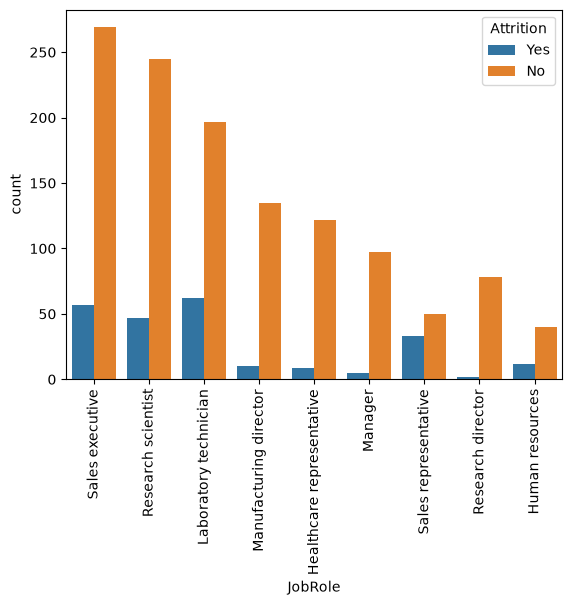

In [187]:
sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)
plt.xticks(rotation=90)

In [188]:
df['JobRole'].value_counts()

JobRole
Sales executive              326
Research scientist           292
Laboratory technician        259
Manufacturing director       145
Healthcare representative    131
Manager                      102
Sales representative          83
Research director             80
Human resources               52
Name: count, dtype: int64

- 

# Género

In [209]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

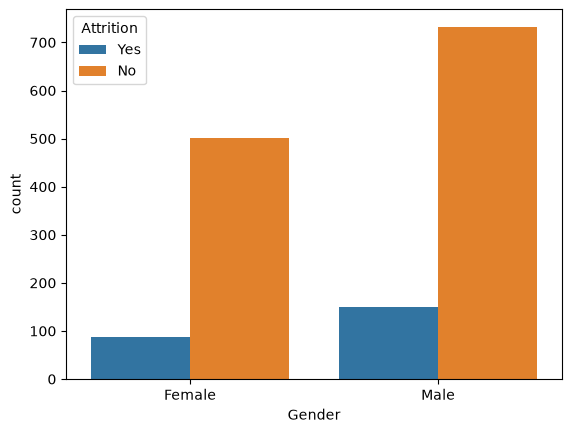

In [189]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition"
)

- Los hombvres se marchan mas 

# Estado civil

<Axes: xlabel='MaritalStatus', ylabel='count'>

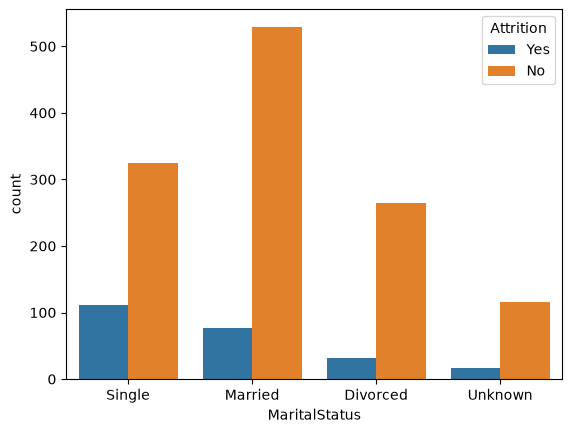

In [190]:
sns.countplot(
    data=df,
    x="MaritalStatus",
    hue="Attrition"
)

- Mayormente casados

# Distancia al trabajo

<Axes: xlabel='Attrition', ylabel='DistanceFromHome'>

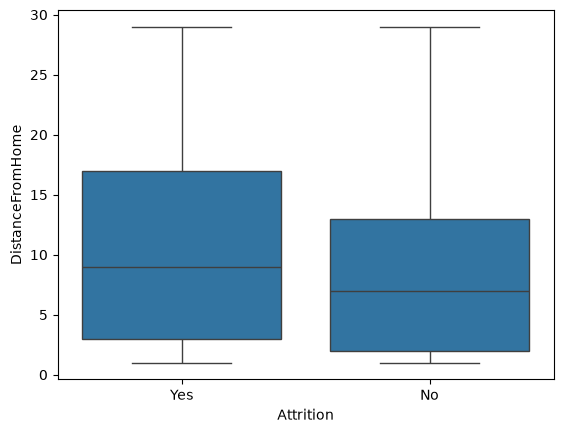

In [191]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

In [192]:
df.groupby("Attrition")["DistanceFromHome"].agg(["mean","median"])

,mean,median
Attrition,,
No,8.915653,7.0
Yes,10.632911,9.0


- La distancia media al trabajo es mayor entre los empleados que abandonan la empresa.

# Años en la empresa

In [193]:
df.groupby("Attrition")["YearsAtCompany"].agg(["mean","median"])

,mean,median
Attrition,,
No,7.369019,6.0
Yes,5.130802,3.0


<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

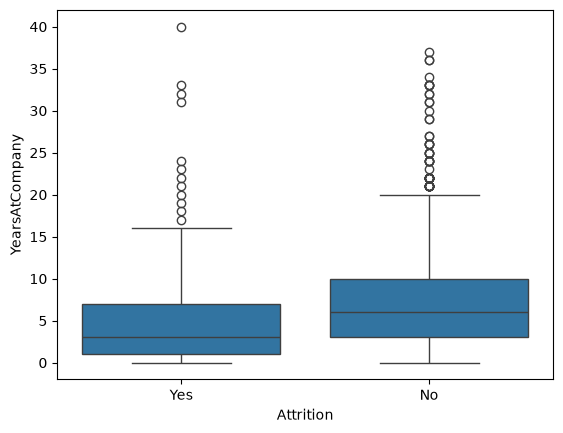

In [194]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

- Se van mas los que llevan menos años en la empresa 

# Viajes

In [195]:
pd.crosstab(
    df["BusinessTravel"],
    df["Attrition"],
    normalize="index"
)*100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,91.366906,8.633094
Travel_Frequently,75.285171,24.714829
Travel_Rarely,85.594111,14.405889
Unknown,80.341880,19.658120


<Axes: xlabel='BusinessTravel', ylabel='count'>

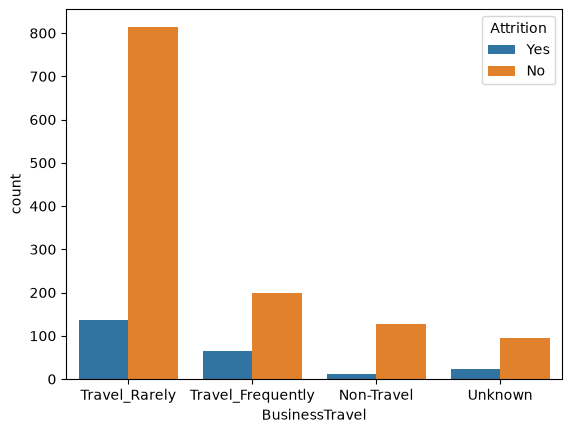

In [196]:
sns.countplot(
    data=df,
    x="BusinessTravel",
    hue="Attrition"
)

- 